In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# **Data Profiling & Cleaning**

### Load the dataset

In [101]:
df = pd.read_csv('Sample_Superstore.csv', encoding='latin-1')

### Initial dataset profiling

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Ship Date     9994 non-null   object 
 4   Ship Mode     9994 non-null   object 
 5   Customer ID   9994 non-null   object 
 6   Segment       9994 non-null   object 
 7   Country       9994 non-null   object 
 8   City          9994 non-null   object 
 9   State         9994 non-null   object 
 10  Region        9994 non-null   object 
 11  Product ID    9994 non-null   object 
 12  Category      9994 non-null   object 
 13  Sub-Category  9994 non-null   object 
 14  Product Name  9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [103]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


###  Understanding the shape and structure

In [104]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Shape: (9994, 19)

Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
 Row ID            int64
Order ID         object
Order Date       object
Ship Date        object
Ship Mode        object
Customer ID      object
Segment          object
Country          object
City             object
State            object
Region           object
Product ID       object
Category         object
Sub-Category     object
Product Name     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


### Check for missing values

In [105]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


### Check for duplicates

In [106]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Fix date columns

In [107]:
# Convert Object type [Order Date, Ship Date] to datetime datatype
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

print(df[['Order Date', 'Ship Date']].dtypes)
print(df[['Order Date', 'Ship Date']].head())

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-11-08 2016-11-11
2 2016-06-12 2016-06-16
3 2015-10-11 2015-10-18
4 2015-10-11 2015-10-18


In [108]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108


In [109]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


### Sales

Mean (229) - Typical order is modest

Min (0.44) - Some near-worthless orders

Max (22638.4) - Large bulk/enterprise orders

Std (623) - Very high, sales are all over the place

The std being 3x larger than the mean tells you sales are heavily skewed — a few big orders are pulling the average up.

### Quantity

Mean (3.79) - Most orders are small quantities

Max (14) - Nobody order huge volumes at once

Pretty clean and expected for a retail store.

### Discount

Mean (15.6) - Average discount across all orders

Max (80) - Someone is getting a 80% discount

75% (20) - Most discounts are 20% or under

Why is there a 80% discount?

### Profit

Mean (28.66) - Average profit per order is low

Min (6599) - Some order lost nearly $6600

Max (8399) - Best order made $8400

Std (234) - Huge variance, very inconsistent profitability

Why is there a -$6,599 minimum profit?

### Summary

- Dataset contains 9,994 rows and 19 columns
- No missing values found
- Order Date and Ship Date had mixed date formats — resolved using format='mixed'
- Sales are heavily right-skewed (mean 229, std 623) — a small number of large orders inflate the average
- Discount ranges from 0% to 80% — extreme discounting present
- Profit has a minimum of - $6599, suggesting heavy discounts are causing significant losses on certain orders
- Average profit per order is only 28.66 despite average sales of 229 — thin margins worth investigating

## **Section 2 - Revenue & Profitability**

### Sales & Profit by Category

In [110]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
print(category_summary)

                     Sales     Profit
Category                             
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95


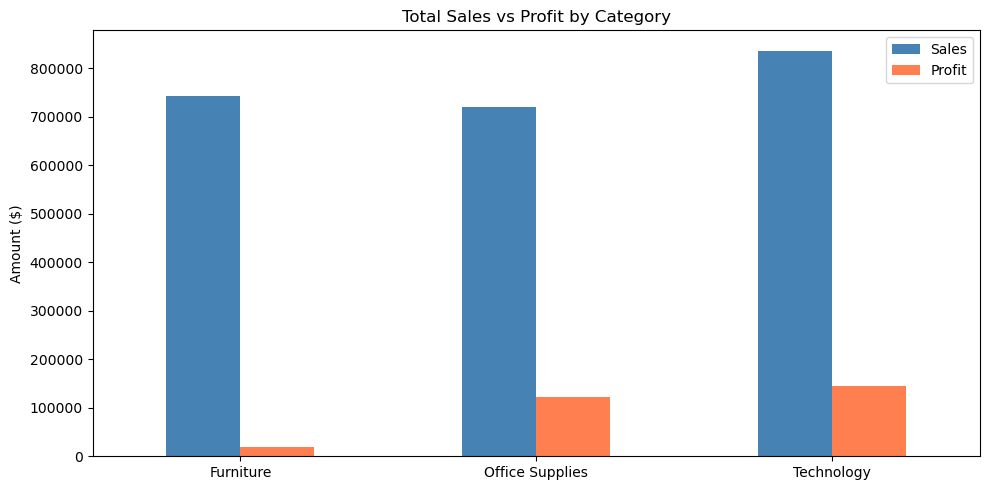

In [111]:
category_summary.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral'])
plt.title('Total Sales vs Profit by Category')
plt.xlabel('')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.legend(['Sales', 'Profit'])
plt.tight_layout()
plt.show()

### Profit Margin by Category

In [112]:
category_summary['Profit Margin %'] = (
    category_summary['Profit'] / category_summary['Sales'] * 100
).round(2)

print(category_summary)

                     Sales     Profit  Profit Margin %
Category                                              
Furniture        741999.80   18451.27             2.49
Office Supplies  719047.03  122490.80            17.04
Technology       836154.03  145454.95            17.40


### Sales & Profit by Sub-Category

In [113]:
sub_category_summary = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().round(2).sort_values('Profit', ascending=False)
print(sub_category_summary)

                  Sales    Profit
Sub-Category                     
Copiers       149528.03  55617.82
Phones        330007.05  44515.73
Accessories   167380.32  41936.64
Paper          78479.21  34053.57
Binders       203412.73  30221.76
Chairs        328449.10  26590.17
Storage       223843.61  21278.83
Appliances    107532.16  18138.01
Furnishings    91705.16  13059.14
Envelopes      16476.40   6964.18
Art            27118.79   6527.79
Labels         12486.31   5546.25
Machines      189238.63   3384.76
Fasteners       3024.28    949.52
Supplies       46673.54  -1189.10
Bookcases     114880.00  -3472.56
Tables        206965.53 -17725.48


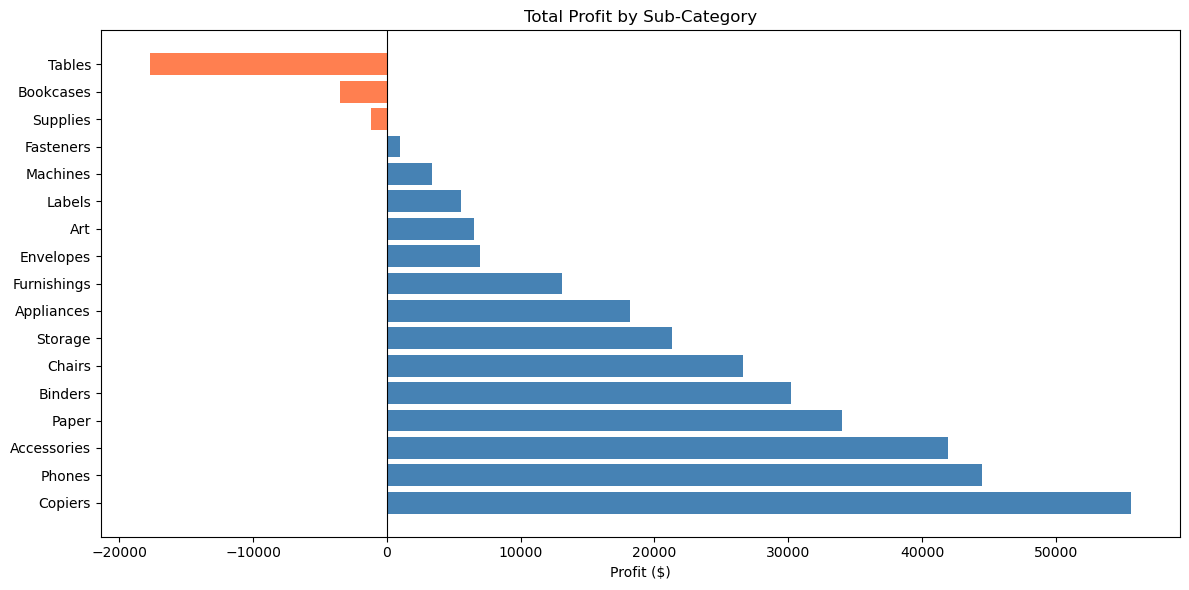

In [114]:
plt.figure(figsize=(12, 6))
colors = ['coral' if x < 0 else 'steelblue' for x in sub_category_summary['Profit']]
plt.barh(sub_category_summary.index, sub_category_summary['Profit'], color=colors)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Section 2 Findings — Revenue & Profitability

### Category Level
- Technology is the most profitable category (145,455) with a 17.4% margin
- Office Supplies follows closely at 17.04% margin despite lower sales than Furniture
- Furniture is the weakest performer — 741,999 in sales but only 2.49% margin
  meaning the business keeps just 2.49 for every $100 of Furniture sold

### Sub-Category Level
- 3 sub-categories are actively losing money: Tables (-17,725), Bookcases (-3,472), and Supplies (-$1,189)
- Tables is the most alarming — it is the 4th highest selling sub-category yet generates the largest loss in the entire dataset
- Copiers is the star performer — relatively low sales (149k) but highest profit (55,617), suggesting strong margins with minimal discounting
- Machines sells 189k but profits only 3,384 — suspiciously low margin worth investigating alongside discount data
  
### Hypothesis
Heavy discounting on Furniture sub-categories (especially **Tables**) appears to be eroding margins.

## **Section 3 - Geographic Analysis**

### Sales & Profit by Region

In [115]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
region_summary['Profit Margin %'] = (
    region_summary['Profit'] / region_summary['Sales'] * 100
).round(2)

print(region_summary)

             Sales     Profit  Profit Margin %
Region                                        
Central  501239.89   39706.36             7.92
East     678781.24   91522.78            13.48
South    391721.90   46749.43            11.93
West     725457.82  108418.45            14.94


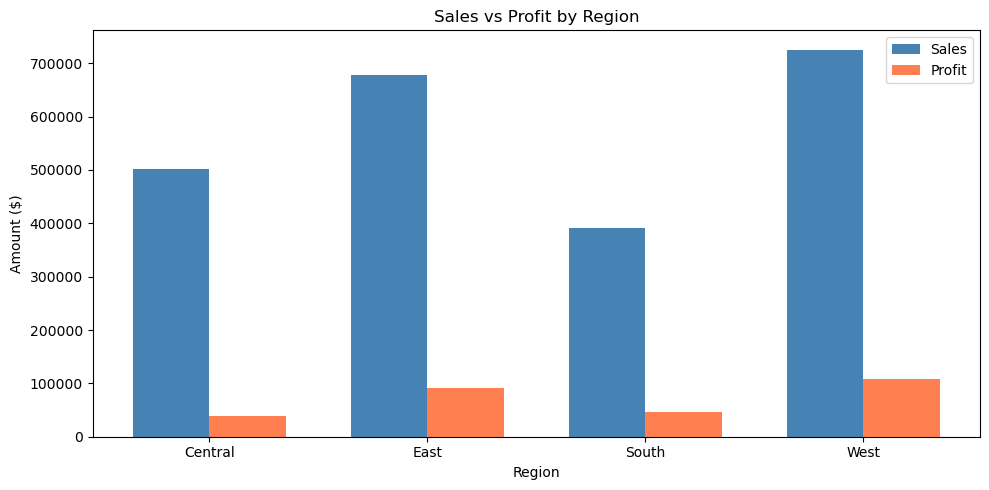

In [116]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(region_summary))
width = 0.35

ax.bar([i - width/2 for i in x], region_summary['Sales'], width, label='Sales', color='steelblue')
ax.bar([i + width/2 for i in x], region_summary['Profit'], width, label='Profit', color='coral')

ax.set_title('Sales vs Profit by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(region_summary.index)
ax.legend()
plt.tight_layout()
plt.show()

### Top 10 States by Sales

In [117]:
state_sales = df.groupby('State')[['Sales', 'Profit']].sum().round(2)
state_sales['Profit Margin %'] = (
    state_sales['Profit'] / state_sales['Sales'] * 100
).round(2)

top10 = state_sales.sort_values('Sales', ascending=False).head(10)
print(top10)

                  Sales    Profit  Profit Margin %
State                                             
California    457687.63  76381.39            16.69
New York      310876.27  74038.55            23.82
Texas         170188.05 -25729.36           -15.12
Washington    138641.27  33402.65            24.09
Pennsylvania  116511.91 -15559.96           -13.35
Florida        89473.71  -3399.30            -3.80
Illinois       80166.10 -12607.89           -15.73
Ohio           78258.14 -16971.38           -21.69
Michigan       76269.61  24463.19            32.07
Virginia       70636.72  18597.95            26.33


### Bottom 10 States by Profit

In [118]:
bottom10 = state_sales.sort_values('Profit').head(10)
print(bottom10)

                    Sales    Profit  Profit Margin %
State                                               
Texas           170188.05 -25729.36           -15.12
Ohio             78258.14 -16971.38           -21.69
Pennsylvania    116511.91 -15559.96           -13.35
Illinois         80166.10 -12607.89           -15.73
North Carolina   55603.16  -7490.91           -13.47
Colorado         32108.12  -6527.86           -20.33
Tennessee        30661.87  -5341.69           -17.42
Arizona          35282.00  -3427.92            -9.72
Florida          89473.71  -3399.30            -3.80
Oregon           17431.15  -1190.47            -6.83


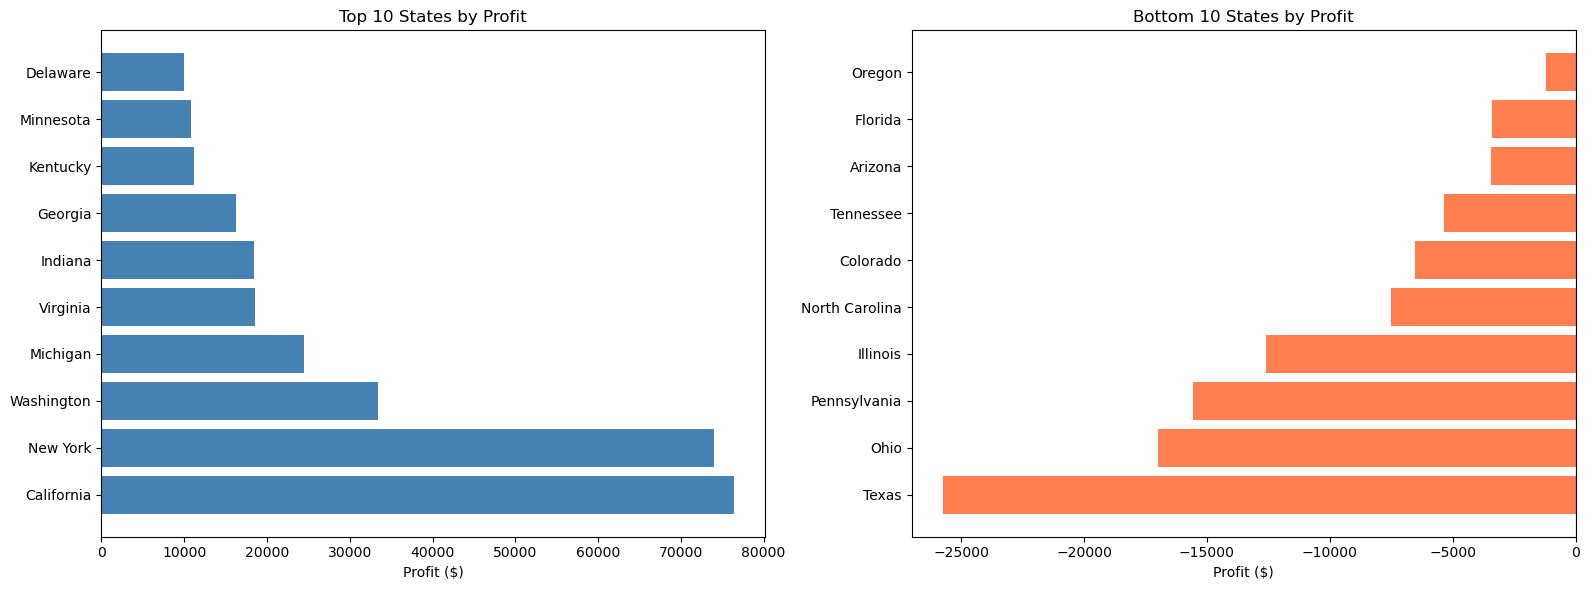

In [119]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
top10_profit = state_sales.sort_values('Profit', ascending=False).head(10)
ax1.barh(top10_profit.index, top10_profit['Profit'], color='steelblue')
ax1.set_title('Top 10 States by Profit')
ax1.set_xlabel('Profit ($)')

# Bottom 10
bottom10_profit = state_sales.sort_values('Profit').head(10)
colors = ['coral' if x < 0 else 'steelblue' for x in bottom10_profit['Profit']]
ax2.barh(bottom10_profit.index, bottom10_profit['Profit'], color=colors)
ax2.set_title('Bottom 10 States by Profit')
ax2.set_xlabel('Profit ($)')
ax2.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## Section 3 Findings — Geographic Analysis

### Regional Level
- West is the **strongest** region with 14.94% profit margin and highest sales (725k)
- East follows at 13.48% margin with 678k in sales
- Central is the **weakest** region — 501k in sales but only 7.92% margin,
  less than half of West's margin despite similar sales volume
- South sits in the middle at 11.93% margin

### State Level
- California is the top state by both sales (457k) and profit (76k) at 16.69% margin
- New York is the most efficient large state at 23.82% margin
- Texas is the most alarming finding — 3rd highest sales ($170k) yet loses 25,729 at a -15.12% margin
- Ohio, Pennsylvania and Illinois follow a similar pattern — high sales, negative profit
- All 10 bottom states are loss-making, suggesting systematic **over-discounting**
  in certain regions

### Key Observation
The pattern of high-sales, loss-making states (Texas, Ohio, Pennsylvania) 
strongly suggests aggressive discounting is being applied in the **Central** 
region without regard for profitability.

## **Section 4 - Customer & Segment Analysis**

### Sales & Profit by Segment

In [120]:
segment_summary = df.groupby('Segment')[['Sales', 'Profit']].sum().round(2)
segment_summary['Profit Margin %'] = (
    segment_summary['Profit'] / segment_summary['Sales'] * 100
).round(2)
segment_summary['Avg Order Value'] = (
    df.groupby('Segment')['Sales'].mean().round(2)
)

print(segment_summary)

                  Sales     Profit  Profit Margin %  Avg Order Value
Segment                                                             
Consumer     1161401.34  134119.21            11.55           223.73
Corporate     706146.37   91979.13            13.03           233.82
Home Office   429653.15   60298.68            14.03           240.97


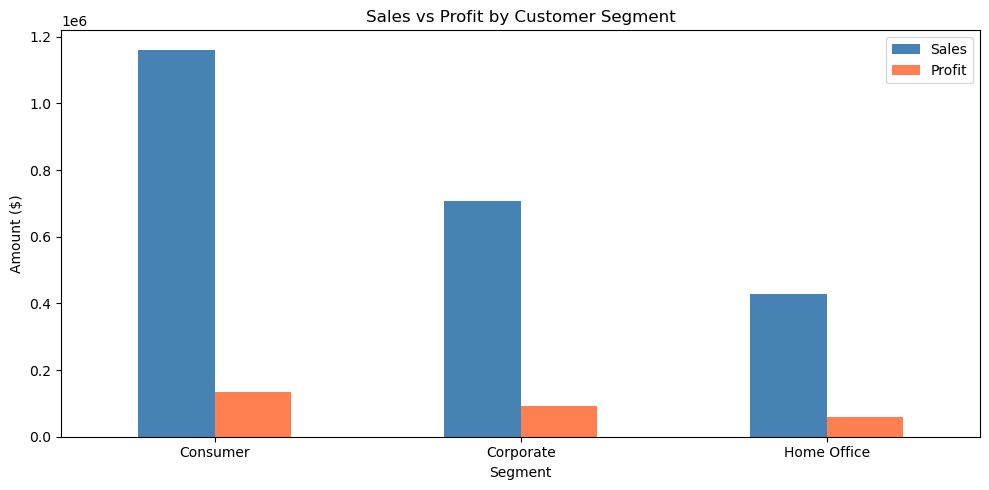

In [121]:
segment_summary[['Sales', 'Profit']].plot(kind='bar', figsize=(10, 5), 
                                           color=['steelblue', 'coral'])
plt.title('Sales vs Profit by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.legend(['Sales', 'Profit'])
plt.tight_layout()
plt.show()

### Discount vs Profit

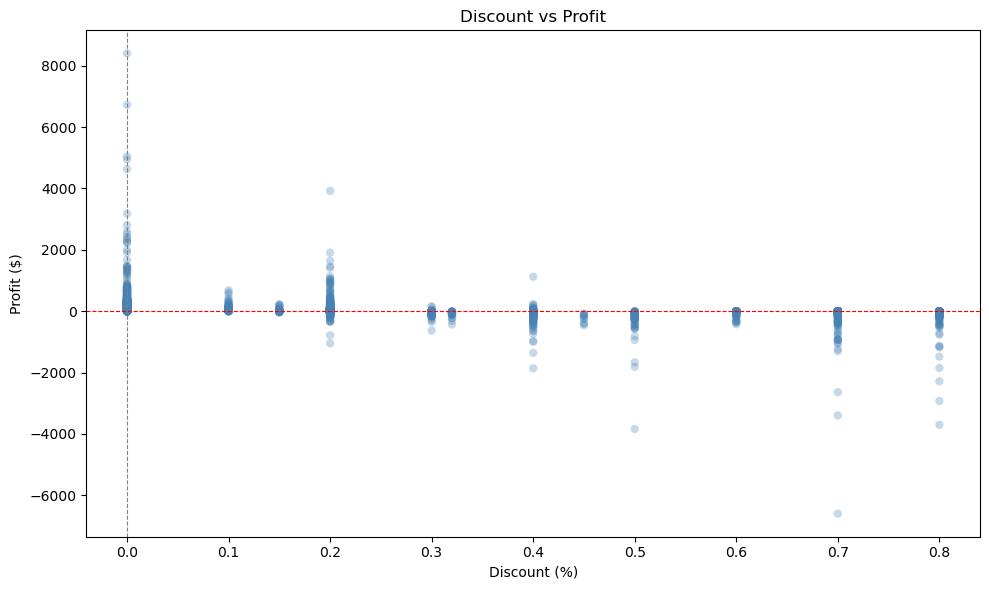

In [122]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue', edgecolors='none')
plt.title('Discount vs Profit')
plt.xlabel('Discount (%)')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='red', linewidth=0.8, linestyle='--')
plt.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### Quantify the Discount Impact

In [123]:
# Average profit by discount bucket
df['Discount Bucket'] = pd.cut(df['Discount'], 
                                bins=[-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                                labels=['0%', '1-10%', '11-20%', '21-30%', 
                                        '31-40%', '41-50%', '50%+'])

discount_analysis = df.groupby('Discount Bucket', observed=True)[['Sales', 'Profit']].mean().round(2)
discount_analysis['Profit Margin %'] = (
    discount_analysis['Profit'] / discount_analysis['Sales'] * 100
).round(2)

print(discount_analysis)

                  Sales  Profit  Profit Margin %
Discount Bucket                                 
0%               226.74   66.90            29.51
1-10%            578.40   96.06            16.61
11-20%           213.58   24.74            11.58
21-30%           454.74  -45.68           -10.05
31-40%           561.85 -109.22           -19.44
41-50%           836.41 -298.70           -35.71
50%+              75.03  -89.44          -119.21


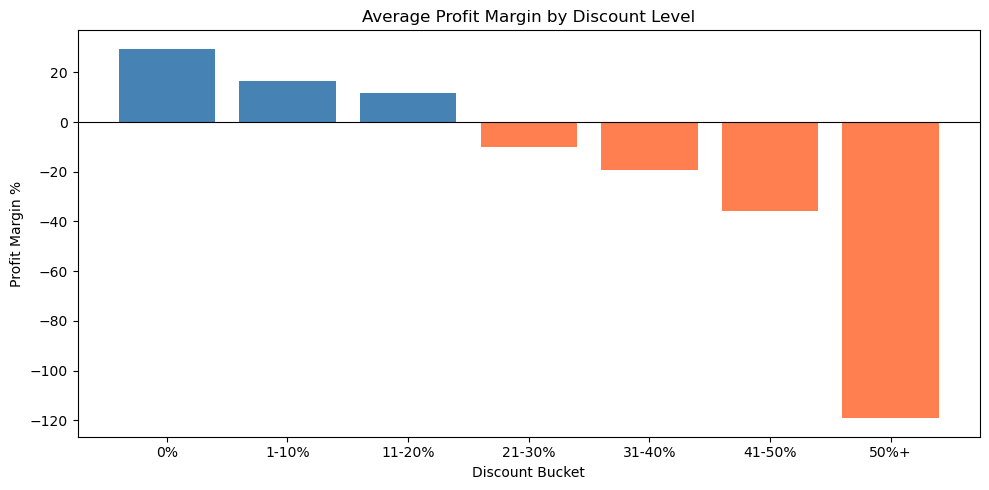

In [124]:
plt.figure(figsize=(10, 5))
colors = ['coral' if x < 0 else 'steelblue' for x in discount_analysis['Profit Margin %']]
plt.bar(discount_analysis.index, discount_analysis['Profit Margin %'], color=colors)
plt.title('Average Profit Margin by Discount Level')
plt.xlabel('Discount Bucket')
plt.ylabel('Profit Margin %')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Correlation Check

          Sales  Quantity  Discount  Profit
Sales      1.00      0.20     -0.03    0.48
Quantity   0.20      1.00      0.01    0.07
Discount  -0.03      0.01      1.00   -0.22
Profit     0.48      0.07     -0.22    1.00


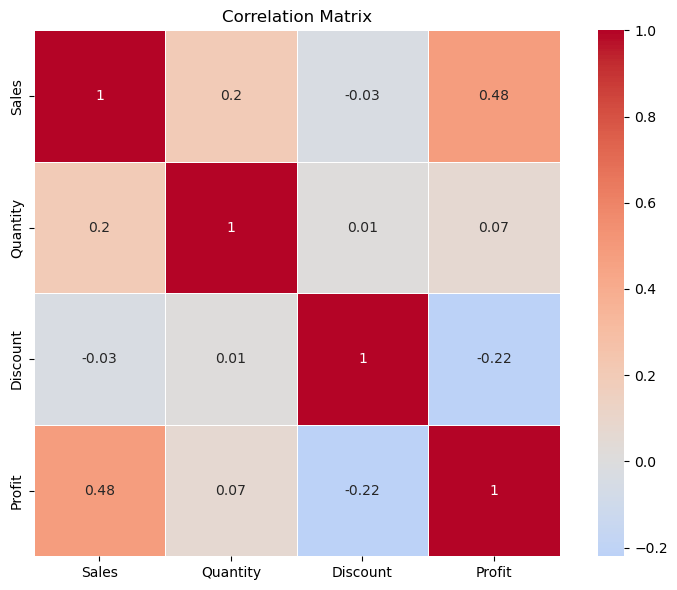

In [125]:
correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr().round(2)
print(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Section 4 Findings — Customer & Segment Analysis

### Segment Level
- Consumer is the largest segment (1.16M sales) but least efficient at 11.55% margin
- Home Office is the smallest segment but most profitable at 14.03% margin with the highest average order value of $240.97
- Corporate sits in the middle at 13.03% margin

### Discount vs Profit — The Core Finding
- Orders with 0% discount average a 29.51% profit margin
- The profitability tipping point is at 20% discount — every order discounted above 20% loses money without exception
- Orders discounted 50%+ have a -119% margin — the business loses more than it earns on these orders
- The scatter plot shows a clear downward trend — as discount increases, profit consistently falls below zero

### Correlation Analysis
- Discount vs Profit correlation is -0.22 — confirmed negative relationship
- Most critically, Discount vs Sales correlation is only -0.03 — discounting is not even driving more sales volume, meaning it is pure margin destruction
- Sales vs Profit at 0.48 suggests the business should focus on growing revenue rather than offering discounts to stimulate demand

### Root Cause Conclusion
Across all 4 sections, a single pattern emerges: excessive discounting above 20% is the primary driver of losses in **Tables**, **Bookcases**, **Texas**, **Ohio**, **Pennsylvania** and the **Central** region. The data suggests an immediate cap on discounts at 20% would significantly improve overall profitability.

## **Recommendations**

1. Cap discounts at 20% — all orders above this threshold lose money
   without generating meaningfully more sales volume

2. Review the Tables sub-category pricing — $17,725 in losses despite
   being the 4th highest selling sub-category suggests a fundamental
   pricing or cost problem

3. Investigate the Central region and loss-making states (Texas, Ohio,
   Pennsylvania) — apply the same discount cap and monitor margin recovery